<h3><b>Implementation of Deep Feed Forward Neural Network (DFFNN) with Adam Algorithm for Multiclass Classification Tasks with Learning Rate Decay</b></h3>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time 
import h5py

In [153]:
def onehot_encoding(Y):
    
    num_classes = len(np.unique(Y))
    one_hot_Y = np.eye(num_classes)[Y].T

    return one_hot_Y

In [154]:
Y = np.array([0,1,2,1,0,2])
print(Y.shape)
Y = onehot_encoding(Y)
print(Y)
print(Y.shape)

(6,)
[[1. 0. 0. 0. 1. 0.]
 [0. 1. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 1.]]
(3, 6)


In [155]:
def layer_sizes(X, Y, num_hidden_units):
    
    num_input_units = X.shape[0]
    num_output_units = Y.shape[0]
    num_layer_units = [num_input_units] + list(num_hidden_units) + [num_output_units]

    return num_layer_units

In [156]:
X = np.random.rand(4, 100)
num_layer_units = layer_sizes(X, Y, np.array([4]))
print(num_layer_units)

[4, 4, 3]


In [157]:
def initialize_parameters(num_layer_units):
    parameters = {}
    L = len(num_layer_units)

    for l in range(1, L):
        parameters[f"W{l}"] = np.random.randn(num_layer_units[l], num_layer_units[l-1]) * np.sqrt(2 / num_layer_units[l-1])
        parameters[f"b{l}"] = np.zeros((num_layer_units[l], 1))
        
    return parameters

In [158]:
params = initialize_parameters(num_layer_units)
params

{'W1': array([[ 1.3145303 ,  0.0580313 , -0.30969635, -0.47121143],
        [ 0.2562755 , -0.19904339, -0.11009853,  0.27164647],
        [-0.21819621, -0.17367192, -0.65683822,  0.5021707 ],
        [-0.41110886, -0.21145451, -0.87147395,  0.22683414]]),
 'b1': array([[0.],
        [0.],
        [0.],
        [0.]]),
 'W2': array([[-0.01862532,  0.8550068 , -0.10864271,  1.11880463],
        [ 0.16193763,  0.91087897, -0.9367627 ,  0.65252407],
        [-1.42248042,  0.2404883 ,  0.58038668, -0.45054428]]),
 'b2': array([[0.],
        [0.],
        [0.]])}

In [159]:
def initialize_adam_parameters(parameters):
    
    V = {}
    S = {}
    L = len(parameters) // 2
    
    for l in range(1, L+1):
        
        V[f"vdW{l}"] = np.zeros(parameters[f"W{l}"].shape)
        V[f"vdb{l}"] = np.zeros(parameters[f"b{l}"].shape)

        S[f"sdW{l}"] = np.zeros(parameters[f"W{l}"].shape)
        S[f"sdb{l}"] = np.zeros(parameters[f"b{l}"].shape)

    return (V, S)

In [160]:
V, S = initialize_adam_parameters(params)
print(V)
print(S)

{'vdW1': array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]]), 'vdb1': array([[0.],
       [0.],
       [0.],
       [0.]]), 'vdW2': array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]]), 'vdb2': array([[0.],
       [0.],
       [0.]])}
{'sdW1': array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]]), 'sdb1': array([[0.],
       [0.],
       [0.],
       [0.]]), 'sdW2': array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]]), 'sdb2': array([[0.],
       [0.],
       [0.]])}


In [161]:
def relu(Z):

    A = np.maximum(0, Z)
    activation_cache = Z

    return (A, activation_cache)

In [162]:
def backward_relu(dA, Z):

    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    
    return dZ

In [163]:
def softmax(Z):

    A = np.divide(np.exp(Z), np.sum(np.exp(Z), axis=0, keepdims=True)+1e-15)
                  
    activation_cache = Z
    
    return (A, activation_cache)

In [187]:
def backward_softmax(dAL, Z):
    
    A = np.divide(np.exp(Z), np.sum(np.exp(Z), axis=0, keepdims=True)+1e-15)
    dZ = A * (1 - A) * dAL  
    return dZ

In [165]:
def forward_propagation(X, parameters):

    A = X
    L = len(parameters) // 2
    caches = []
    
    for l in range(1, L):
        
        W = parameters[f"W{l}"]
        b = parameters[f"b{l}"]
        A_prev = A
        linear_cache = (A_prev, W, b)
        
        Z = np.dot(W, A_prev) + b
        A, activation_cache = relu(Z)

        caches.append((linear_cache, activation_cache))

    W =  parameters[f"W{L}"] 
    b = parameters[f"b{L}"]
    A_prev = A
    linear_cache = (A_prev, W, b)
        
    Z = np.dot(W, A_prev) + b
    A, activation_cache = softmax(Z)

    caches.append((linear_cache, activation_cache))

    return A, caches        

In [166]:
def compute_cost(A, Y):
  
    #  m = len(Y)
    A = np.clip(A, 1e-15, 1 - 1e-15)
    
    cost = - np.sum(Y * np.log(A)) #  / m

    return cost

In [167]:
def backward_propagation(AL, Y, caches):
    
    Y = Y.reshape(AL.shape)
    L = len(caches)
    gradients = {}

    dAL = - (np.divide(Y, AL + 1e-15) - np.divide(1 - Y, 1 - AL + 1e-15))

    (linear_cache, activation_cache) = caches[-1]
    (A_prev, W, b) = linear_cache
    m = A_prev.shape[1]

    dZ = backward_softmax(dAL, activation_cache)
    gradients[f"dA{L-1}"] = np.dot(W.T, dZ)
    gradients[f"dW{L}"] = 1 / m * np.dot(dZ, A_prev.T)
    gradients[f"db{L}"] = 1 / m * np.sum(dZ, axis=1, keepdims=True)

    for l in reversed(range(L - 1)):

        (linear_cache, activation_cache) = caches[l]
        (A_prev, W, b) = linear_cache
        m = A_prev.shape[1]

        dZ = backward_relu(gradients[f"dA{l+1}"], activation_cache)
        gradients[f"dA{l}"] = np.dot(W.T, dZ)
        gradients[f"dW{l+1}"] = 1 / m * np.dot(dZ, A_prev.T)
        gradients[f"db{l+1}"] = 1 / m * np.sum(dZ, axis=1, keepdims=True)

    return gradients

In [168]:
def compute_momentum(parameters, gradients, V, beta, beta_correction, t):
    
    L = len(parameters) // 2

    for l in range(1, L + 1):
        
        V[f"vdW{l}"] = (beta * V[f"vdW{l}"]) + ((1 - beta) * gradients[f"dW{l}"])
        V[f"vdb{l}"] = (beta * V[f"vdb{l}"]) + ((1 - beta) * gradients[f"db{l}"])
        
        # bias correction terms
        if beta_correction:
            V[f"vdW{l}"] = V[f"vdW{l}"] / (1 - np.power(beta, t))
            V[f"vdb{l}"] = V[f"vdb{l}"] / (1 - np.power(beta, t))
        
    return V

In [169]:
def compute_squared_gradients(parameters, gradients, S, beta, beta_correction, t):
    
    L = len(parameters) // 2

    for l in range(1, L + 1):
        
        S[f"sdW{l}"] = (beta * S[f"sdW{l}"]) + ((1 - beta) * np.power(gradients[f"dW{l}"], 2))
        S[f"sdb{l}"] = (beta * S[f"sdb{l}"]) + ((1 - beta) * np.power(gradients[f"db{l}"], 2))
        
        # bias correction terms
        if beta_correction:
            S[f"sdW{l}"] = S[f"sdW{l}"] / (1 - np.power(beta, t))
            S[f"sdb{l}"] = S[f"sdb{l}"] / (1 - np.power(beta, t))
        
    return S 

In [170]:
def update_parameters(parameters, V, S, learning_rate, epsilon):

    L = len(parameters) // 2

    for l in range(1, L + 1):
        
        parameters[f"W{l}"] -= learning_rate * (V[f"vdW{l}"] / np.sqrt(S[f"sdW{l}"] + epsilon))
        parameters[f"b{l}"] -= learning_rate * (V[f"vdb{l}"] / np.sqrt(S[f"sdb{l}"] + epsilon))

    return parameters

In [171]:
def update_learning_rate(init_learning_rate, epoch_num, decay_rate, time_interval):
  
    learning_rate = (1 * init_learning_rate) / (1 + decay_rate * (np.floor(epoch_num / time_interval)))
    
    return learning_rate

In [172]:
def predict(X, parameters):

    A, _ = forward_propagation(X, parameters)

    return A

In [173]:
def accuracy(A, Y):
    
    assert(A.shape == Y.shape)
    
    predicted_labels = np.argmax(A, axis=0)
    true_labels = np.argmax(Y, axis=0)
    
    accuracy = np.mean(predicted_labels == true_labels)

    return accuracy

In [174]:
def random_mini_batches(X, Y, mini_batch_size, seed):

    np.random.seed(seed) 
    m = X.shape[1] 
    n = Y.shape[0]
    mini_batches = []
        
    
    permutation = np.random.permutation(m)
    shuffled_X = X[:, permutation]
    shuffled_Y = Y[:, permutation].reshape((n, m))
    
    # Step 2: Partition the shuffled data into mini-batches
    num_complete_minibatches = m // mini_batch_size  
    
    for k in range(num_complete_minibatches):
        start_idx = k * mini_batch_size
        end_idx = (k + 1) * mini_batch_size
        mini_batch_X = shuffled_X[:, start_idx:end_idx]
        mini_batch_Y = shuffled_Y[:, start_idx:end_idx]
        mini_batches.append((mini_batch_X, mini_batch_Y))
    
    # Handling the end case (last mini-batch may have fewer examples)
    if m % mini_batch_size != 0:
        start_idx = num_complete_minibatches * mini_batch_size
        mini_batch_X = shuffled_X[:, start_idx:]
        mini_batch_Y = shuffled_Y[:, start_idx:]
        mini_batches.append((mini_batch_X, mini_batch_Y))
    
    return mini_batches

In [175]:
def train(X_train, Y_train, X_test, Y_test, num_hidden_units, num_epochs=1000, learning_rate=1e-3, beta1=0.9, beta2=0.999,
          decay_rate=0.3, time_interval=100, mini_batch_size=64, beta_correction=False, epsilon=1e-8, print_cost=100, seed=1):
    
    train_time = 0
    cost_ = []
    learning_rates = [learning_rate]
   
    Y_train = onehot_encoding(Y_train)
    Y_test = onehot_encoding(Y_test)
    
    num_layer_units = layer_sizes(X_train, Y_train, num_hidden_units)
    parameters = initialize_parameters(num_layer_units)
    (V, S) = initialize_adam_parameters(parameters)
    
    init_learning_rate = learning_rate
    epoch_num = 0
    m = X_train.shape[1]
    t = 0
    for i in range(num_epochs):

        tic = time.time()
        seed = seed + 1
        minibatches = random_mini_batches(X_train, Y_train, mini_batch_size, seed)
        cost_total = 0
        
        for minibatch in minibatches:

            (X_minibatch, Y_minibatch) = minibatch 
            A_minibatch, minibatch_caches = forward_propagation(X_minibatch, parameters)
            cost_total += compute_cost(A_minibatch, Y_minibatch)
            gradients = backward_propagation(A_minibatch, Y_minibatch, minibatch_caches)
            t += 1
            V = compute_momentum(parameters, gradients, V, beta1, beta_correction, t)
            S = compute_squared_gradients(parameters, gradients, S, beta2, beta_correction, t)
            parameters = update_parameters(parameters, V, S, learning_rate, epsilon)
        
        toc = time.time()
        train_time += toc - tic
        cost_.append(cost_total / m)
        epoch_num += 1
        learning_rate = update_learning_rate(init_learning_rate, epoch_num, decay_rate, time_interval)
        learning_rates.append(learning_rate)
        if i % print_cost == 0:
            print(f"Epoch: {i}; Cost: {cost_total / m}")
            train_accuracy = accuracy(predict(X_train, parameters), Y_train)
            test_accuracy = accuracy(predict(X_test, parameters), Y_test)
            print(f"Train Accuracy: {train_accuracy}")
            print(f"Test Accuracy: {test_accuracy}")
            print()
            
    train_accuracy = accuracy(predict(X_train, parameters), Y_train)
    test_accuracy = accuracy(predict(X_test, parameters), Y_test)
    
    print(f"Train Accuracy: {train_accuracy}")
    print(f"Test Accuracy: {test_accuracy}")
    print(f"Train Duration: {train_time}")

    plt.plot(cost_)
    plt.title("epoch vs. cost")
    plt.xlabel("# epoch")
    plt.ylabel("cost")
    
    return (parameters, cost_, train_time, learning_rates) 

In [176]:
train_data = h5py.File("/home/samani/Documents/projects/deep-learning/data/train_signs.h5", "r")
test_data = h5py.File("/home/samani/Documents/projects/deep-learning/data/test_signs.h5", "r")

In [177]:
print(train_data.keys())
print(test_data.keys())

<KeysViewHDF5 ['list_classes', 'train_set_x', 'train_set_y']>
<KeysViewHDF5 ['list_classes', 'test_set_x', 'test_set_y']>


In [178]:
train_x = np.array(train_data["train_set_x"][:])
train_y = np.array(train_data["train_set_y"][:])
test_x = np.array(test_data["test_set_x"][:])
test_y = np.array(test_data["test_set_y"][:])

In [179]:
print(train_x.shape)
print(train_y.shape)
print(test_x.shape)
print(test_y.shape)

(1080, 64, 64, 3)
(1080,)
(120, 64, 64, 3)
(120,)


In [180]:
def visualize_images(images, labels, num_images=6):
    
    row_imgs = num_images // 3
    imgs = [np.random.choice([i for i in range(images.shape[0])]) for _ in range(num_images)]
    
    plt.figure(figsize=(12, 8))
    
    for i in range(row_imgs):
        for j in range(3):
            plt.subplot(row_imgs, 3, i * 3 + j + 1)
            plt.imshow(images[imgs[i * 3 + j]])
            plt.title(f"Label: {labels[imgs[i * 3 + j]]}")
            plt.axis('off')
    plt.show()

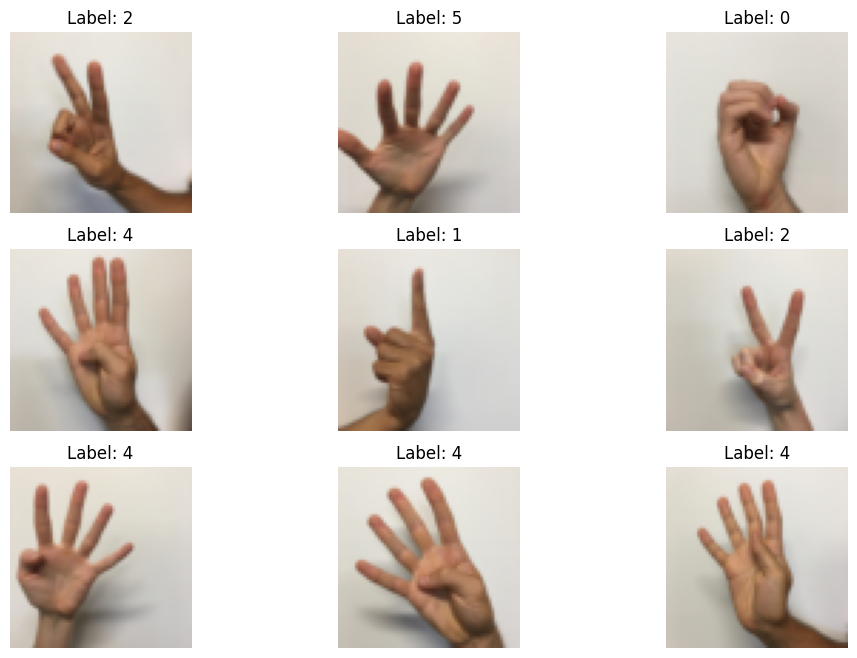

In [181]:
visualize_images(train_x, train_y, 9)

In [182]:
X_train = train_x.reshape(train_x.shape[0], -1).T
Y_train = train_y
X_test = test_x.reshape(test_x.shape[0], -1).T
Y_test = test_y

In [183]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(12288, 1080)
(1080,)
(12288, 120)
(120,)


In [184]:
X_train = X_train / 255.0
X_test = X_test / 255.0

Epoch: 0; Cost: 1.821753751042915
Train Accuracy: 0.17314814814814813
Test Accuracy: 0.19166666666666668

Epoch: 50; Cost: 1.2910339835581501
Train Accuracy: 0.5037037037037037
Test Accuracy: 0.475

Epoch: 100; Cost: 1.0472979694186362
Train Accuracy: 0.6175925925925926
Test Accuracy: 0.575

Epoch: 150; Cost: 0.921551722522626
Train Accuracy: 0.6685185185185185
Test Accuracy: 0.575

Epoch: 200; Cost: 0.8383398373365714
Train Accuracy: 0.6898148148148148
Test Accuracy: 0.6166666666666667

Epoch: 250; Cost: 0.8000481310003889
Train Accuracy: 0.7203703703703703
Test Accuracy: 0.5833333333333334

Epoch: 300; Cost: 0.7413290590113051
Train Accuracy: 0.7398148148148148
Test Accuracy: 0.6083333333333333

Epoch: 350; Cost: 0.701522013113945
Train Accuracy: 0.7546296296296297
Test Accuracy: 0.6166666666666667

Epoch: 400; Cost: 0.6565562812393156
Train Accuracy: 0.7703703703703704
Test Accuracy: 0.6333333333333333

Epoch: 450; Cost: 0.6278037374668365
Train Accuracy: 0.7453703703703703
Test Acc

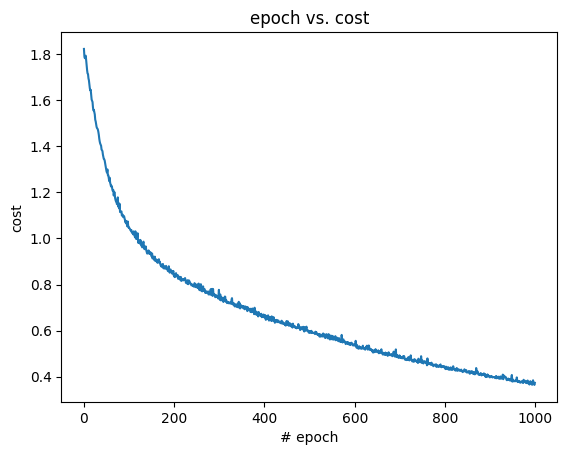

In [185]:
model = train(
    X_train=X_train, 
    Y_train=Y_train, 
    X_test=X_test, 
    Y_test=Y_test,
    num_hidden_units=[25, 15, 10], 
    num_epochs=1000, 
    learning_rate=1e-4, 
    beta1=0.9, 
    beta2=0.9,
    decay_rate=0.3, 
    time_interval=200, 
    mini_batch_size=32, 
    beta_correction=False, 
    epsilon=1e-8, 
    print_cost=50, 
    seed=1
)
    

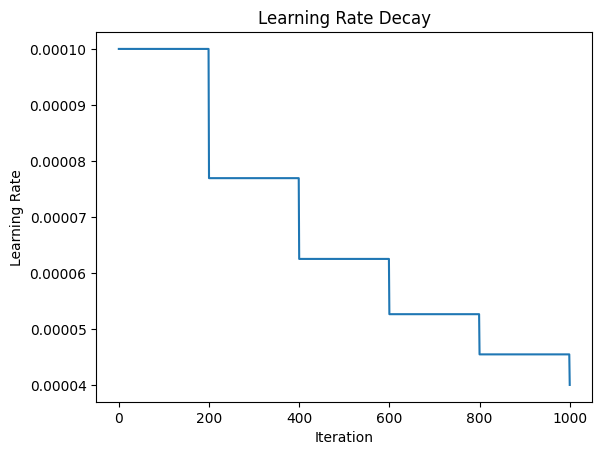

In [186]:
plt.plot(model[-1])
plt.title("Learning Rate Decay")
plt.xlabel("Iteration")
plt.ylabel("Learning Rate")
plt.show()